# Dynamic programming (DP)



Idea of breaking down a larger problems recursively into subproblems

Programming: optimising a “program”, i.e. a policy

Breaking into subproblems:
- Solve the subproblems
- Combine solutions to subproblems

Dynamic Programming is a very general solution method for problems which have two properties:
- Optimal substructure
    Optimal solution can be decomposed into subproblems
- Overlapping subproblems
    Subproblems recur many times
    Solutions can be cached and reused

Markov decision processes satisfy both properties
- Bellman equation gives recursive decomposition
- Value function stores and reuses solutions


## Planning by DP

Dynamic programming assumes full knowledge of the MDP (Requires a perfect model of env.)
It is used for planning in an MDP. 

Planning = simulate future trajectories using a model of env to improve policy/value estimate. Instead of learning purely from real experience, the agent "thinks ahead" by querying an internal model

Full knowledge: 
- transitions: next state
- rewards



Nb: DP used to solve other problems like sequence alignement (string), graph algo (shortest path), graphical model (viterbi),...


## Iterative Policy evaluation (Prediction)

Problem: evaluate a given policy $\pi$
Solution: iterative application of Bellman expectation

v1 -> v2 -> v3 -> ... -> $v_\pi$


Use synchronous backup:
- at each iteration k
- for all states (synchronous)
- update $v_{k+1}(s)$ from $v_k(s')$
- s' is successor state




How to compute action-value function

From previous section we know:

<img src="./imgs/image-66.png" width="500px" /><div/>


State-value function is the average of all the available action-values, weighted by how likely we are to choose them under our current policy:

We apply the Bellmann equation as an update rule, and compute for each state

<img src="./imgs/image-67.png" width="500px" /><div/>



### Example with simple grid

<img src="./imgs/image-76.png" width="500px" /><div/>

- Undiscounted episodic MDP (γ = 1)
- Nonterminal states 1,...,14
- One terminal state (shown twice as shaded squares)
- Actions leading out of the grid leave state unchanged
- Reward is −1 until the terminal state is reached
- Agent follows uniform random policy (1/4 (actions)=0.25)
    


k=0: Value initialized to 0
k=1: value = reward (synchronous -> we evaluate all states)
k=2: 
    -2 (immediate reward + prev value)
    -   

<img src="./imgs/image-77.png" width="500px" /><div/>

<img src="./imgs/image-78.png" width="500px" /><div/>



<img src="./imgs/image-68.png" width="700px" /><div/>

###### Code implementation

Bellman equation to update V: 

$V(s)\leftarrow r(s)+\gamma\sum_{s'}P(s'|s)V(s')$

In [1]:
import numpy as np

# ---------- MDP definition (dicts) ----------
states = ["Class1", "Class2", "Class3", "Facebook", "Pub", "Pass", "Sleep"]
terminal_states = ["Sleep"]  # , "Pass"]
state_names = ["C1", "C2", "C3", "FB", "Sleep"]  
    
S = list(state_names)  # ["C1", "C2", "C3", "FB", "Sleep"]
terminal_states_mdp = {"Sleep"}

A = {
    "C1": ["study", "facebook"],
    "C2": ["study", "sleep"],
    "C3": ["study", "pub"],
    "FB": ["quit", "facebook"],
    "Sleep": [],
}

# Transition model: P[(s,a)] = [(prob, s_next), ...]
P_sa = {
    ("C1", "study"): [(1.0, "C2")],
    ("C1", "facebook"): [(1.0, "FB")],
    ("C2", "study"): [(1.0, "C3")],
    ("C2", "sleep"): [(1.0, "Sleep")],
    # Study in C3 gives +10 then day ends
    ("C3", "study"): [(1.0, "Sleep")],
    # Pub in C3 transitions back to class states
    ("C3", "pub"): [(0.2, "C1"), (0.4, "C2"), (0.4, "C3")],
    ("FB", "quit"): [(1.0, "C1")],
    ("FB", "facebook"): [(1.0, "FB")],
}

# Reward model: R[(s,a)] = immediate reward for taking action a in s
R_sa = {
    ("C1", "study"): -2.0,
    ("C1", "facebook"): -1.0,
    ("C2", "study"): -2.0,
    ("C2", "sleep"): 0.0,
    ("C3", "study"): 10.0,
    ("C3", "pub"): 1.0,
    ("FB", "quit"): 0.0,
    ("FB", "facebook"): -1.0,
}

# not used
r = {
    "Class1": -2.0,
    "Class2": -2.0,
    "Class3": -2.0,
    "Facebook": -1.0,
    "Pub": 1.0,
    "Sleep": 0.0,
    "Pass": 10.0,
}

def actions(s):
    return A[s]


def transitions_sa(s, a):
    return P_sa[(s, a)]


def reward_sa(s, a):
    return float(R_sa[(s, a)])



In [6]:
transitions_sa("C3", "pub")
actions("C1")

['study', 'facebook']

In [9]:
# Iterative policy evaluation on the student MDP using the uniform random policy

V = {s: 0.0 for s in S}
gamma = 0.9
theta = 1e-6

def iterative_policy_evaluation(V, S, terminal_states_mdp, gamma, theta, policy=None):
    iterations = 0
    while True:
        delta = 0.0
        V_new = {}

        for s in S:
            if s in terminal_states_mdp:
                V_new[s] = 0.0
                continue

            v = 0.0

            # uniform random policy
            prob_a = 1.0 / len(actions(s))
            for a in actions(s):
                q_sa = 0.0
                for p, s_next in transitions_sa(s, a):
                    q_sa += p * (reward_sa(s, a) + gamma * V[s_next])
                v += prob_a * q_sa


            V_new[s] = v
            delta = max(delta, abs(V_new[s] - V[s]))

        V = V_new
        iterations += 1

        if delta < theta:
            break

    return V, iterations



V,iterations = iterative_policy_evaluation(V, S, terminal_states_mdp, gamma, theta)


print(f"Converged in {iterations} iterations\n")
print("State values under uniform random policy:")
for s in S:
    print(f"  {s:>5}: {V[s]: .6f}")

Converged in 41 iterations

State values under uniform random policy:
     C1: -1.484479
     C2:  2.158158
     C3:  7.018128
     FB: -2.123666
  Sleep:  0.000000


#### Policy improvement

From predicting value (estimation) -> move to control problem

Given a policy π
- Evaluate the policy π
    $$v_π(s) = E [R_{t+1} + γR_{t+2} +...|S_t = s]$$
- Improve the policy by acting greedily with respect to $v_π$
$$π' = greedy(v_π)$$

Always converge to $\pi*$ , optimal policy

<img src="./imgs/image-79.png" width="600px" /><div/>

- Consider a deterministic policy, a = π(s)
- We can improve the policy by acting greedily
$$\pi'(s) = \underset{a \in \mathcal{A}}{\argmax} \; q_\pi(s, a)$$
- improves the value from any state s over one step,
- It therefore improves the value function, $v_π′ (s) ≥ v_π (s)$
- if improvement stop: 
$$q_\pi(s, \pi'(s)) = \max_{a \in \mathcal{A}} q_\pi(s, a) \geq q_\pi(s, \pi(s)) = v_\pi(s)$$
- then bellman optimality is satisfied -> $\pi$ is optimal policy

When should we stop:
- $\epsilon$-convergence  as a stop condition. Improvement is smaller than $\epsilon$
- stop after k iterations

#### Generalized policy iteration

Policy evaluation Estimate vπ

-> Any policy evaluation algorithm

Policy improvement Generate π′≥π

-> Any policy improvement algorithm

#### Principle of optimality
Any optimal policy can be subdivided into two components:
- An optimal first action A∗
- Followed by an optimal policy from successor state S′

##### Theorem (Principle of Optimality)
A policy π(a|s) achieves the optimal value from state s, vπ (s) = v∗(s), if and only if

- For any state s′reachable from s
- π achieves the optimal value from state s′, $v_π (s′) = v_∗(s′)$





Similarly, the action-value function is the average value of the states the agent might transition to given the chosen action, but weighted instead by their transition probabilities

<img src="./imgs/image-69.png" width="500px" /><div/>

<img src="./imgs/image-44.png" width="600px" /><div/>

We do a one step policy improvement

#### Backup diagram

<img src="./imgs/image-75.png" width="600px" /><div/>




So action-value is the immediate reward for taking that action, plus the expected value of the next state, over all possible successor states

If this is better than the value of π, we are better off changing our policy in such a way. And we can indeed answer such question via the policy improvement theorem, which states that if, for all states s:

<img src="./imgs/image-70.png" width="200px" /><div/>

The improved policy is better:

<img src="./imgs/image-71.png" width="200px" /><div/>




## Policy iteration

chain these improvement steps with policy evaluation


<img src="./imgs/image-72.png" width="700px" /><div/>

Each of the resulting policies are monotonically improving, and — since finite MDPs only have finite states — this process must converge to the optimal policy eventually!

So first algorithm for solving an RL problem — called policy iteration


<img src="./imgs/image-73.png" width="700px" /><div/>


In [16]:



def policy_iteration(S, terminal_states_mdp, gamma, theta):
    """
    Policy iteration algorithm.

    Returns:
        V: optimal state-value function
        policy: optimal policy (dict mapping state -> action)
        iterations: number of policy iterations
    """
    # Initialize policy arbitrarily (choose first available action for each state)
    policy = {}
    for s in S:
        if s not in terminal_states_mdp:
            policy[s] = actions(s)[0]

    iterations = 0

    while True:
        iterations += 1

        # Policy Evaluation: compute V under current policy
        V = {s: 0.0 for s in S}
        V, _ = iterative_policy_evaluation(V, S, terminal_states_mdp, gamma, theta, policy=policy)

        # Policy Improvement: act greedily with respect to V
        policy_stable = True

        for s in S:
            if s in terminal_states_mdp:
                continue

            old_action = policy[s]

            # Find best action by computing q(s,a) for all actions
            best_action = None
            best_value = float('-inf')

            for a in actions(s):
                q_sa = 0.0
                for p, s_next in transitions_sa(s, a):
                    q_sa += p * (reward_sa(s, a) + gamma * V[s_next])

                if q_sa > best_value:
                    best_value = q_sa
                    best_action = a

            policy[s] = best_action

            if old_action != best_action:
                policy_stable = False

        # If policy is stable, we've found the optimal policy
        if policy_stable:
            break

    return V, policy, iterations

V, policy, iterations = policy_iteration(S, terminal_states_mdp, gamma, theta)    

Policy iteration converged in 1 iteration(s)

State       V*(s)      pi*(s)
-----------------------------
C1         4.3000       study
C2         7.0000       study
C3        10.0000       study
FB         3.8700        quit
Sleep      0.0000    TERMINAL


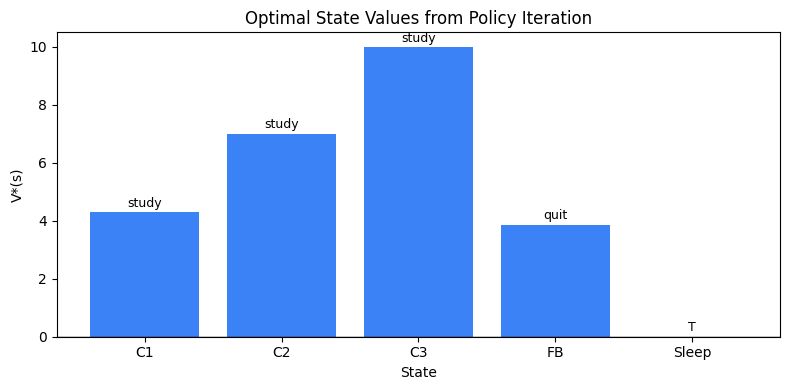

In [17]:
print(f"Policy iteration converged in {iterations} iteration(s)\n")

# Text table
state_w = max(len(s) for s in S)
header = f"{'State':<{state_w}}  {'V*(s)':>10}  {'pi*(s)':>10}"
print(header)
print("-" * len(header))
for s in S:
    action = "TERMINAL" if s in terminal_states_mdp else policy[s]
    print(f"{s:<{state_w}}  {V[s]:>10.4f}  {action:>10}")

# Simple value plot
import matplotlib.pyplot as plt

values = [V[s] for s in S]
colors = ["#9ca3af" if s in terminal_states_mdp else "#3b82f6" for s in S]

plt.figure(figsize=(8, 4))
bars = plt.bar(S, values, color=colors)
plt.axhline(0.0, color="black", linewidth=1)
plt.title("Optimal State Values from Policy Iteration")
plt.ylabel("V*(s)")
plt.xlabel("State")

for bar, s in zip(bars, S):
    label = "T" if s in terminal_states_mdp else policy[s]
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y + (0.08 if y >= 0 else -0.2),
        label,
        ha="center",
        va="bottom" if y >= 0 else "top",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


## Value iteration

- Find optimal policy
- Solution: iterative application of Bellman optimality backup
- $v_1$ -> $v_2$ -> ... -> $v_*$

- use synchronous backup
    - at each iteration k+1
    - for all states $s\in S$
    - update $v_{k+1}(s)$ from $v_k(s')$, value at next iteration k+1 is updated with value of next state à iteration k

- there is no explicit policy 
- Intermediate value functions may not correspond to any policy

<img src="./imgs/image-80.png" width="500px" />


Optimal value function V*:
     C1:  4.300000
     C2:  7.000000
     C3:  10.000000
     FB:  3.870000
  Sleep:  0.000000

Greedy optimal policy π*:
     C1 -> study
     C2 -> study
     C3 -> study
     FB -> quit
  Sleep -> TERMINAL


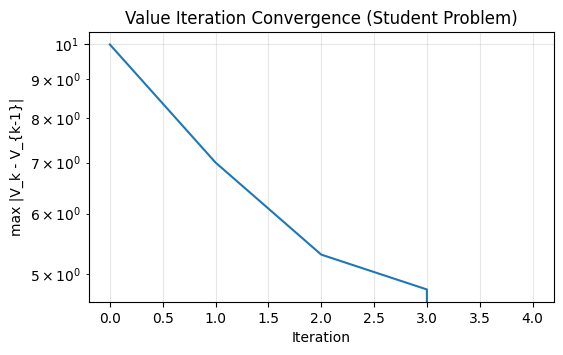

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def value_iteration_dict(S, terminal_states_mdp, gamma=0.9, theta=1e-8, max_iters=10_000):
    """
    Value iteration for the student MDP defined with dicts:
    - actions(s)
    - transitions_sa(s, a) -> list[(p, s_next)]
    - reward_sa(s, a)
    """
    V = {s: 0.0 for s in S}
    deltas = []

    for _ in range(max_iters):
        delta = 0.0
        V_new = {}

        for s in S:
            if s in terminal_states_mdp:
                V_new[s] = 0.0
                continue

            best_q = float("-inf")
            for a in actions(s):
                q_sa = 0.0
                for p, s_next in transitions_sa(s, a):
                    q_sa += p * (reward_sa(s, a) + gamma * V[s_next])
                if q_sa > best_q:
                    best_q = q_sa

            V_new[s] = best_q
            delta = max(delta, abs(V_new[s] - V[s]))

        V = V_new
        deltas.append(delta)
        if delta < theta:
            break

    # Greedy policy extraction
    policy = {}
    for s in S:
        if s in terminal_states_mdp:
            continue

        best_a = None
        best_q = float("-inf")
        for a in actions(s):
            q_sa = 0.0
            for p, s_next in transitions_sa(s, a):
                q_sa += p * (reward_sa(s, a) + gamma * V[s_next])
            if q_sa > best_q:
                best_q = q_sa
                best_a = a
        policy[s] = best_a

    return V, policy, deltas


# Run
V_star, pi_star, deltas = value_iteration_dict(
    S, terminal_states_mdp, gamma=gamma, theta=theta
)

print("Optimal value function V*:")
for s in S:
    print(f"  {s:>5}: {V_star[s]: .6f}")

print("\nGreedy optimal policy π*:")
for s in S:
    if s in terminal_states_mdp:
        print(f"  {s:>5} -> TERMINAL")
    else:
        print(f"  {s:>5} -> {pi_star[s]}")

# Convergence plot
plt.figure(figsize=(6, 3.5))
plt.plot(deltas)
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("max |V_k - V_{k-1}|")
plt.title("Value Iteration Convergence (Student Problem)")
plt.grid(True, alpha=0.3)
plt.show()

## Synchronous Dynamic Programming Algorithms

| Problem | Bellman Equation | Algorithm |
|---|---|---|
| Prediction | Bellman Expectation Equation | Iterative Policy Evaluation |
| Control | Bellman Expectation Equation + Greedy Policy Improvement | Policy Iteration |
| Control | Bellman Optimality Equation | Value Iteration |

## Jack's car Rental

Optimal Policy (cars moved overnight):
[[ 0  0 -1 -1 -2 -2 -3 -3 -3 -4 -4 -5 -5 -5 -5 -5 -5 -5 -5 -5 -5]
 [ 1  0  0 -1 -1 -2 -2 -2 -3 -3 -4 -4 -5 -5 -5 -5 -5 -5 -5 -5 -5]
 [ 1  1  0  0 -1 -1 -1 -2 -2 -3 -3 -4 -4 -5 -5 -5 -5 -5 -5 -5 -5]
 [ 2  1  1  0  0  0 -1 -1 -2 -2 -3 -3 -4 -4 -5 -5 -5 -5 -5 -5 -5]
 [ 2  2  1  1  1  0  0 -1 -1 -2 -2 -3 -3 -4 -4 -5 -5 -5 -5 -5 -5]
 [ 3  2  2  2  1  1  0  0 -1 -1 -2 -2 -3 -3 -4 -4 -5 -5 -5 -5 -5]
 [ 3  3  3  2  2  1  1  0  0 -1 -1 -2 -2 -3 -3 -4 -5 -5 -5 -5 -5]
 [ 4  4  3  3  2  2  1  1  0  0 -1 -1 -2 -2 -3 -4 -4 -4 -4 -5 -5]
 [ 5  4  4  3  3  2  2  1  1  0  0 -1 -1 -2 -3 -3 -3 -3 -4 -4 -5]
 [ 5  5  4  4  3  3  2  2  1  1  0  0 -1 -2 -2 -2 -2 -3 -3 -4 -4]
 [ 5  5  5  4  4  3  3  2  2  1  1  0 -1 -1 -1 -1 -2 -2 -3 -3 -4]
 [ 5  5  5  5  4  4  3  3  2  2  1  0  0  0  0 -1 -1 -2 -2 -3 -3]
 [ 5  5  5  5  5  4  4  3  3  2  1  1  1  1  0  0 -1 -1 -2 -2 -3]
 [ 5  5  5  5  5  5  4  4  3  2  2  2  2  1  1  0  0 -1 -1 -2 -2]
 [ 5  5  5  5  5  5  5  4  3  3  3  3

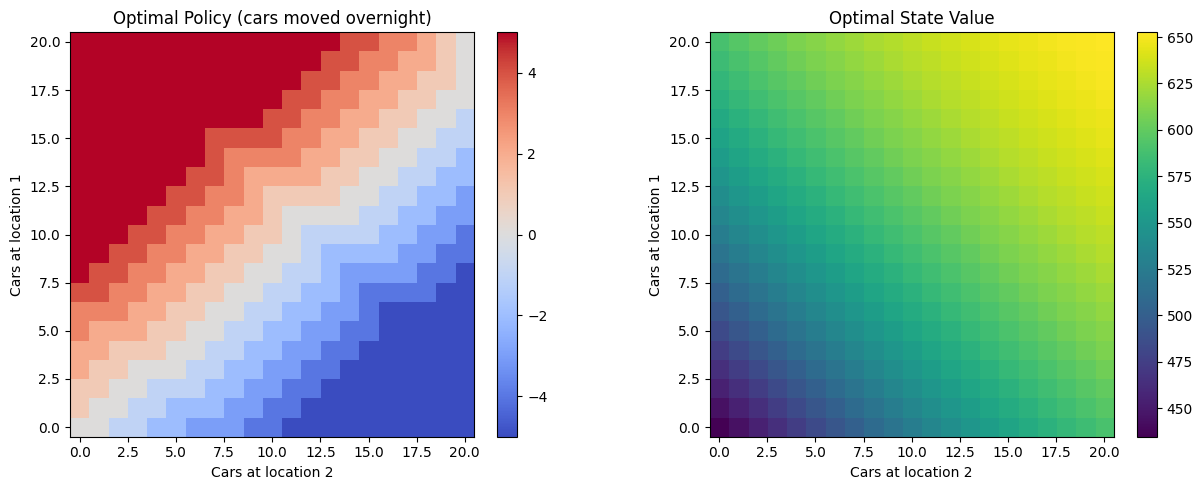

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Output current policy/value if they already exist in the notebook state
if "policy_jack" in globals() and "V_jack" in globals():
    print("Optimal Policy (cars moved overnight):")
    print(policy_jack)
    print("\nOptimal State Value:")
    print(V_jack)

# Jack's Car Rental (policy iteration)
max_cars = 20
max_move = 5
rent_reward = 10.0

# Poisson means
req1, ret1 = 3.0, 3.0
req2, ret2 = 4.0, 2.0

# Reuse notebook gamma/theta if already defined
gamma_jack = gamma if "gamma" in globals() else 0.9
theta_jack = 1e-3  # practical stopping threshold
poisson_upper = 11  # truncation for Poisson support


def poisson_pmf(n, lam):
    return math.exp(-lam) * (lam**n) / math.factorial(n)


def poisson_probs(lam, upper):
    probs = np.array([poisson_pmf(n, lam) for n in range(upper)], dtype=float)
    tail = max(0.0, 1.0 - probs.sum())
    probs = np.append(probs, tail)  # index=upper represents ">= upper"
    return probs


req_probs_1 = poisson_probs(req1, poisson_upper)
ret_probs_1 = poisson_probs(ret1, poisson_upper)
req_probs_2 = poisson_probs(req2, poisson_upper)
ret_probs_2 = poisson_probs(ret2, poisson_upper)


def build_location_model(req_probs, ret_probs):
    # For each starting cars c in [0..max_cars]:
    # - expected rentals E[min(req, c)]
    # - transition probs to next cars c'
    exp_rentals = np.zeros(max_cars + 1)
    trans = np.zeros((max_cars + 1, max_cars + 1))

    for c in range(max_cars + 1):
        for req_n, p_req in enumerate(req_probs):
            req_eff = min(req_n, poisson_upper)  # tail bucket at index=upper
            rented = min(c, req_eff)
            exp_rentals[c] += p_req * rented

            cars_after_rent = c - rented
            for ret_n, p_ret in enumerate(ret_probs):
                ret_eff = min(ret_n, poisson_upper)
                next_c = min(max_cars, cars_after_rent + ret_eff)
                trans[c, next_c] += p_req * p_ret

    # Numerical cleanup
    trans = trans / trans.sum(axis=1, keepdims=True)
    return exp_rentals, trans


exp_rent_1, trans_1 = build_location_model(req_probs_1, ret_probs_1)
exp_rent_2, trans_2 = build_location_model(req_probs_2, ret_probs_2)


def valid_actions(i, j):
    # action a > 0 means move a cars from loc1 -> loc2
    acts = []
    for a in range(-max_move, max_move + 1):
        if 0 <= i - a <= max_cars and 0 <= j + a <= max_cars:
            acts.append(a)
    return acts


def expected_return(i, j, a, V):
    i2, j2 = i - a, j + a
    reward = rent_reward * (exp_rent_1[i2] + exp_rent_2[j2])

    future = 0.0
    p_i = trans_1[i2]
    p_j = trans_2[j2]
    for ni in range(max_cars + 1):
        for nj in range(max_cars + 1):
            future += p_i[ni] * p_j[nj] * V[ni, nj]

    return reward + gamma_jack * future


def policy_iteration_jack(max_eval_iters=200):
    V = np.zeros((max_cars + 1, max_cars + 1), dtype=float)
    policy = np.zeros((max_cars + 1, max_cars + 1), dtype=int)  # start with "move 0"

    stable = False
    it = 0

    while not stable:
        it += 1

        # Policy Evaluation
        for _ in range(max_eval_iters):
            delta = 0.0
            V_new = V.copy()
            for i in range(max_cars + 1):
                for j in range(max_cars + 1):
                    a = int(policy[i, j])
                    V_new[i, j] = expected_return(i, j, a, V)
                    delta = max(delta, abs(V_new[i, j] - V[i, j]))
            V = V_new
            if delta < theta_jack:
                break

        # Policy Improvement
        stable = True
        for i in range(max_cars + 1):
            for j in range(max_cars + 1):
                old_a = int(policy[i, j])
                acts = valid_actions(i, j)
                q_vals = [expected_return(i, j, a, V) for a in acts]
                best_a = acts[int(np.argmax(q_vals))]
                policy[i, j] = best_a
                if best_a != old_a:
                    stable = False

        print(f"Policy iteration step {it} complete | stable={stable}")

    return V, policy, it


V_jack, policy_jack, n_pi_iters = policy_iteration_jack()
print(f"\nConverged in {n_pi_iters} policy-iteration step(s).")

# Visualize policy and value
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im0 = axes[0].imshow(policy_jack, origin="lower", cmap="coolwarm")
axes[0].set_title("Optimal Policy (cars moved overnight)")
axes[0].set_xlabel("Cars at location 2")
axes[0].set_ylabel("Cars at location 1")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(V_jack, origin="lower", cmap="viridis")
axes[1].set_title("Optimal State Value")
axes[1].set_xlabel("Cars at location 2")
axes[1].set_ylabel("Cars at location 1")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()